In [3]:
import psutil
import matplotlib.pyplot as plt
import time
import subprocess

# Number of seconds to monitor
duration = 500
interval = 1  # seconds

# Lists to store measurements
timestamps = []
cpu_usage = []
ram_usage = []
net_sent = []
net_recv = []
temp_cpu = []

# Get initial network stats
net_io_start = psutil.net_io_counters()

print("Monitoring started...")

for i in range(0, duration, interval):
    timestamps.append(i)

    # CPU usage %
    cpu_usage.append(psutil.cpu_percent(interval=None))

    # RAM usage %
    ram = psutil.virtual_memory()
    ram_usage.append(ram.percent)

    # Network usage (bytes sent/recv since start)
    net_io = psutil.net_io_counters()
    net_sent.append((net_io.bytes_sent - net_io_start.bytes_sent)/1024)  # KB
    net_recv.append((net_io.bytes_recv - net_io_start.bytes_recv)/1024)  # KB

    # CPU temperature
    try:
        temp = float(subprocess.check_output(
            ["vcgencmd", "measure_temp"]
        ).decode().split('=')[1].split("'")[0])
    except:
        temp = 0.0
    temp_cpu.append(temp)

    time.sleep(interval)

print("Monitoring finished.")


Monitoring started...
Monitoring finished.


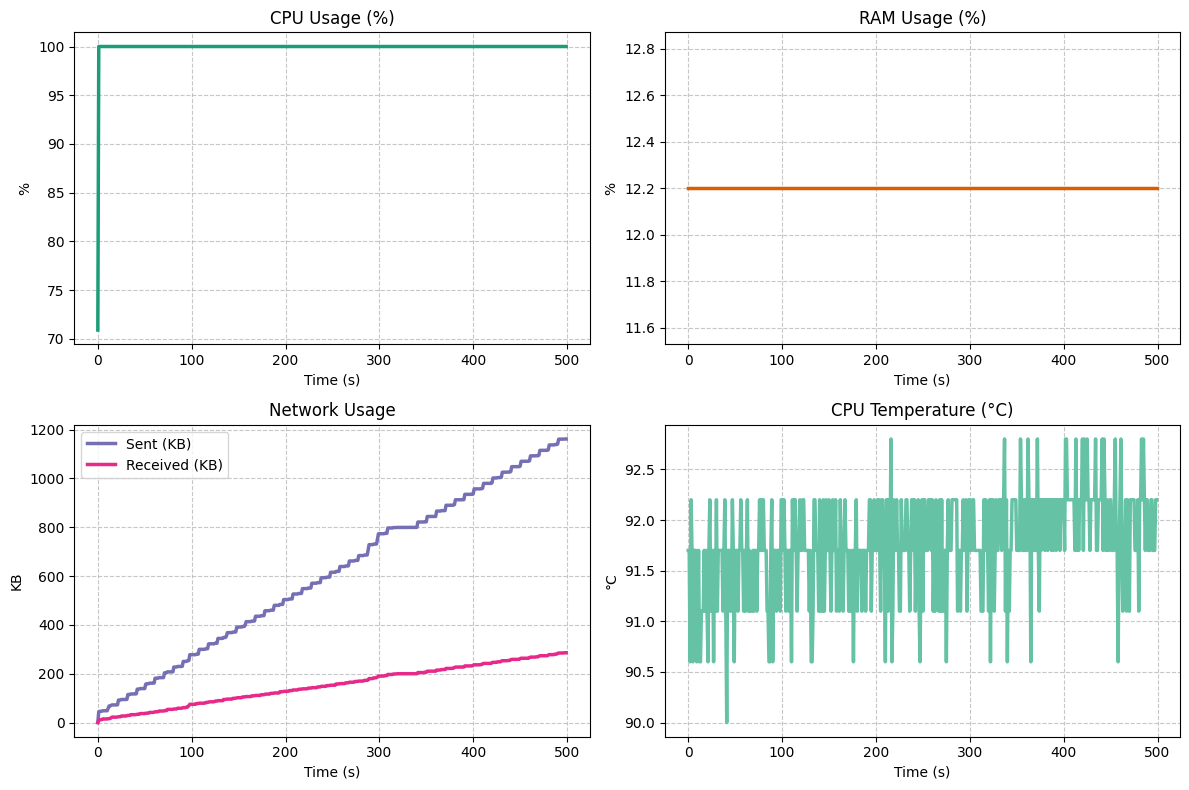

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Define print-quality colors
colors = {
    "cpu": "#1b9e77",       # Green
    "ram": "#d95f02",       # Orange
    "net_sent": "#7570b3",  # Purple
    "net_recv": "#e7298a",  # Pink
    "temp": "#66c2a5"       # Teal
}

# CPU Usage
plt.subplot(2,2,1)
plt.plot(timestamps, cpu_usage, color=colors["cpu"], linewidth=2.5)
plt.title("CPU Usage (%)")
plt.xlabel("Time (s)")
plt.ylabel("%")
plt.grid(True, linestyle='--', alpha=0.7)

# RAM Usage
plt.subplot(2,2,2)
plt.plot(timestamps, ram_usage, color=colors["ram"], linewidth=2.5)
plt.title("RAM Usage (%)")
plt.xlabel("Time (s)")
plt.ylabel("%")
plt.grid(True, linestyle='--', alpha=0.7)

# Network Usage
plt.subplot(2,2,3)
plt.plot(timestamps, net_sent, label="Sent (KB)", color=colors["net_sent"], linewidth=2.5)
plt.plot(timestamps, net_recv, label="Received (KB)", color=colors["net_recv"], linewidth=2.5)
plt.title("Network Usage")
plt.xlabel("Time (s)")
plt.ylabel("KB")
plt.legend(fontsize=10, frameon=True)
plt.grid(True, linestyle='--', alpha=0.7)

# CPU Temperature
plt.subplot(2,2,4)
plt.plot(timestamps, temp_cpu, color=colors["temp"], linewidth=2.5)
plt.title("CPU Temperature (°C)")
plt.xlabel("Time (s)")
plt.ylabel("°C")
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

# Save figure as high-resolution image for journal
plt.savefig("Pi5_Resource_Usage_PrintQuality.png", dpi=600)

plt.show()
